In [ ]:
!nvidia-smi

Mon Jun 15 12:08:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import userdata


In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_1566bd3a1d54e479234e89155d9def79"

In [ ]:
!pip install -q kaggle


In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
import os

token = os.environ["KAGGLE_API_TOKEN"]

with open("/root/.kaggle/access_token", "w") as f:
    f.write(token)

In [ ]:
!chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d dansbecker/food-101

Dataset URL: https://www.kaggle.com/datasets/dansbecker/food-101
License(s): other
100% 9.38G/9.38G [09:11<00:00, 18.3MB/s]



In [ ]:
!unzip -q food-101.zip

replace food-101.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as pltn
import os

In [ ]:
dataset_path = "/content/food-101/food-101/images"
print(len(os.listdir(dataset_path)))
print(os.listdir(dataset_path)[:10])

102
['baklava', 'paella', 'escargots', 'clam_chowder', 'dumplings', 'tacos', 'gnocchi', 'frozen_yogurt', 'lobster_roll_sandwich', 'hot_dog']


In [ ]:
!ls /content

food-101  food-101.zip	sample_data


In [ ]:
!ls /content/food-101

food-101  __MACOSX


In [ ]:
!ls /content/food-101/food-101

images	license_agreement.txt  meta  README.txt


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Found 101000 files belonging to 101 classes.
Using 20200 files for validation.


In [ ]:
class_names = train_ds.class_names

print("Total Classes:", len(class_names))
print(class_names[:10])

Total Classes: 101
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


In [ ]:
import matplotlib.pyplot as plt

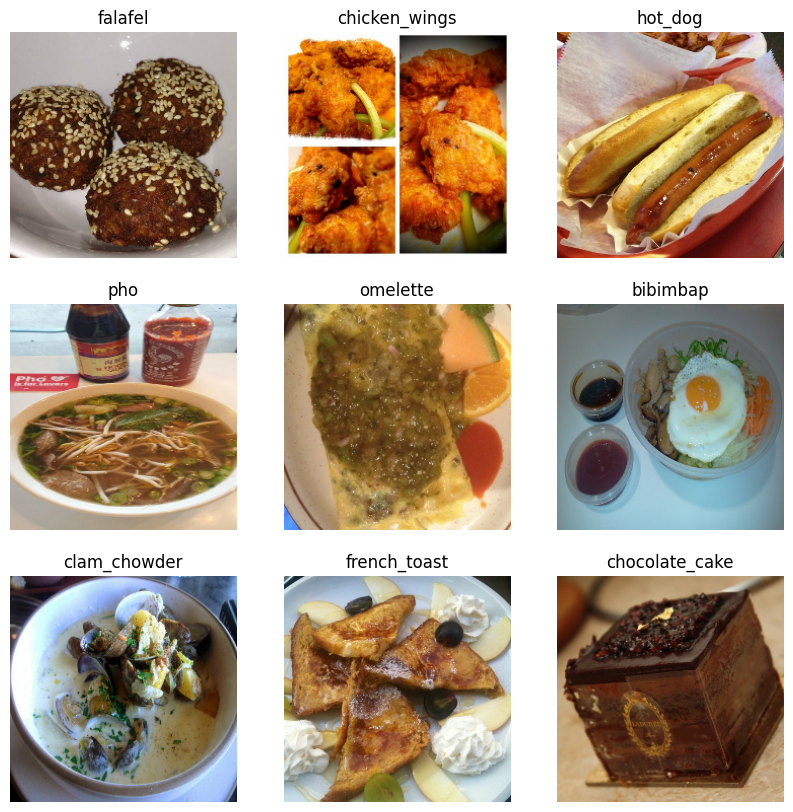

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(101, activation="softmax")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 298s 106ms/step - accuracy: 0.5637 - loss: 1.7787 - val_accuracy: 0.6553 - val_loss: 1.3266
Epoch 2/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 268s 106ms/step - accuracy: 0.6590 - loss: 1.3033 - val_accuracy: 0.6757 - val_loss: 1.2354
Epoch 3/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 223s 88ms/step - accuracy: 0.6827 - loss: 1.1982 - val_accuracy: 0.6855 - val_loss: 1.1984
Epoch 4/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 232s 76ms/step - accuracy: 0.6938 - loss: 1.1431 - val_accuracy: 0.6899 - val_loss: 1.1855
Epoch 5/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 192s 76ms/step - accuracy: 0.7049 - loss: 1.1005 - val_accuracy: 0.6920 - val_loss: 1.1742


In [ ]:
model.save("food_classifier.h5")


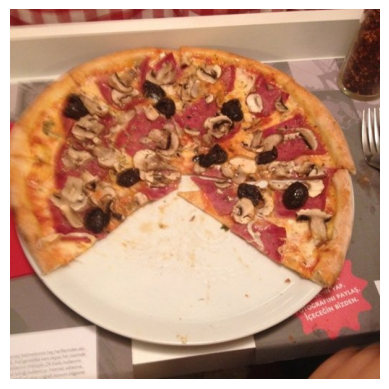

/content/food-101/food-101/images/pizza/2487039.jpg


In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

pizza_folder = "/content/food-101/food-101/images/pizza"

img_name = random.choice(os.listdir(pizza_folder))
img_path = os.path.join(pizza_folder, img_name)

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

print(img_path)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

In [ ]:
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Food :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
Predicted Food : lasagna


In [ ]:
confidence = np.max(prediction) * 100

print("Confidence :", confidence)

Confidence : 7.0963526


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

# Upload image
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Prediction:", predicted_class)
print("Confidence:", confidence)

Saving burger.png to burger (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Prediction: hamburger
Confidence: 99.157425


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
calorie_dict = {
    "pizza": 285,
    "hamburger": 295,
    "apple_pie": 296,
    "ice_cream": 207,
    "sushi": 200,
    "fried_rice": 238,
    "waffles": 312,
    "lasagna": 135
}

calories = calorie_dict.get(predicted_class, "Not Available")

print("Food Item:", predicted_class)
print("Confidence:", round(confidence,2), "%")
print("Estimated Calories:", calories, "kcal")

Food Item: hamburger
Confidence: 99.16 %
Estimated Calories: 295 kcal


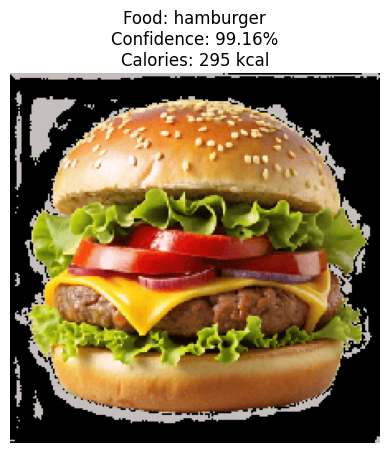

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(
    f"Food: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%\n"
    f"Calories: {calories} kcal"
)
plt.axis("off")
plt.show()